# Weather Scenario Clustering & Weather Index
Cluster days by weather + demand, then build a PCA-based weather index.

**Sections:**
1. Setup
2. Elbow plot — choose K
3. K-Means clustering
4. Cluster profiles & t-SNE visualization
5. PCA — weather index

## 1. Setup

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from dotenv import load_dotenv
from divvy_demand.infra.s3_client import S3Client

load_dotenv("../.env")
s3 = S3Client(env="prod")

overall = s3.read_processed("overall")
overall["date"] = pd.to_datetime(overall["date"])
overall = overall.set_index("date").sort_index()

hist = s3.read_processed("weather/historical")
hist["date"] = pd.to_datetime(hist["date"])
hist = hist.set_index("date").sort_index()

df = overall[["total_rides"]].join(hist, how="inner").dropna()

weather_vars = ["temp_min_c", "rain_sum_mm", "snowfall_sum_cm", "wind_speed_max_kmh"]
cluster_vars = ["temp_min_c", "rain_sum_mm", "snowfall_sum_cm"]  # exclude wind
features = cluster_vars + ["total_rides"]

scaler = StandardScaler()
X = scaler.fit_transform(df[features])

print("Shape:", df.shape)
df.head()

Shape: (2249, 5)


,total_rides,temp_min_c,rain_sum_mm,snowfall_sum_cm,wind_speed_max_kmh
date,,,,,
2020-01-01,2141,-6.1,0.0,0.00,35.7
2020-01-02,6479,2.5,0.0,0.00,32.7
2020-01-03,5890,0.2,0.0,0.00,13.4
2020-01-04,3187,-2.0,0.0,1.40,21.8
2020-01-05,3035,-4.8,0.0,0.07,36.0


## 2. Elbow Plot — Choose K

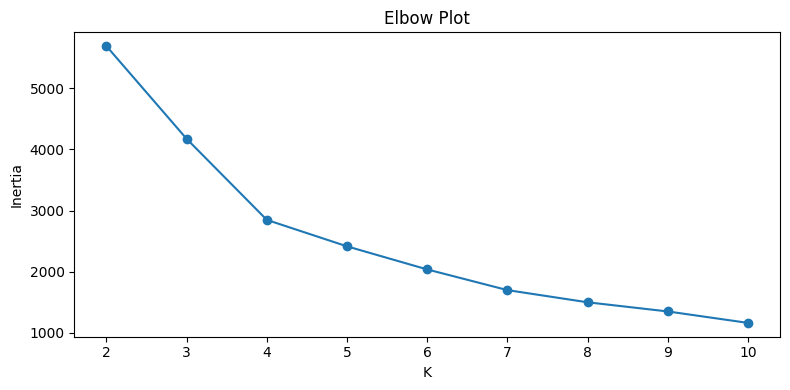

In [57]:
inertias = []
K = range(2, 11)
for k in K:
    inertias.append(KMeans(n_clusters=k, random_state=42, n_init=10).fit(X).inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertias, marker="o")
plt.title("Elbow Plot")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

## 3. K-Means Clustering

In [58]:
K = 4  # set based on elbow

km = KMeans(n_clusters=K, random_state=42, n_init=10)
df["cluster"] = km.fit_predict(X)

profile = df.groupby("cluster")[features].mean().round(1)
profile["count"] = df["cluster"].value_counts().sort_index()
profile

,temp_min_c,rain_sum_mm,snowfall_sum_cm,total_rides,count
cluster,,,,,
0,-4.3,2.3,5.3,3093.4,48
1,-2.0,1.1,0.2,7200.4,1063
2,13.0,23.4,0.0,12509.4,139
3,15.4,1.4,0.0,22758.4,999


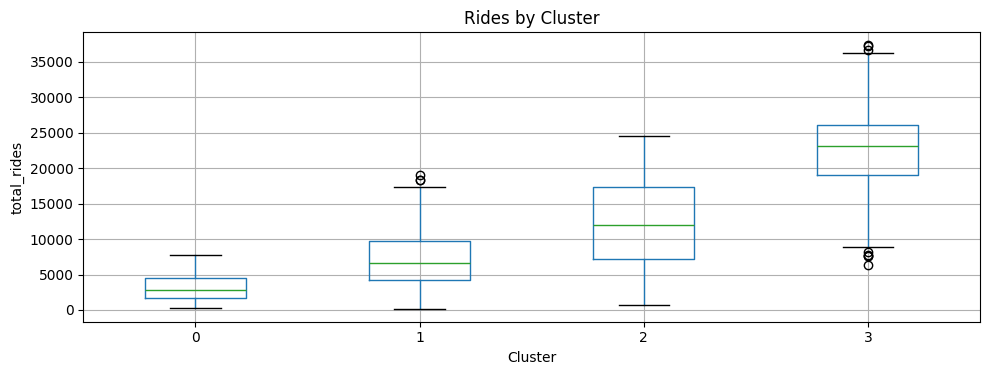

In [59]:
# Rides distribution per cluster
fig, ax = plt.subplots(figsize=(10, 4))
df.boxplot(column="total_rides", by="cluster", ax=ax)
ax.set_title("Rides by Cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("total_rides")
plt.suptitle("")
plt.tight_layout()
plt.show()

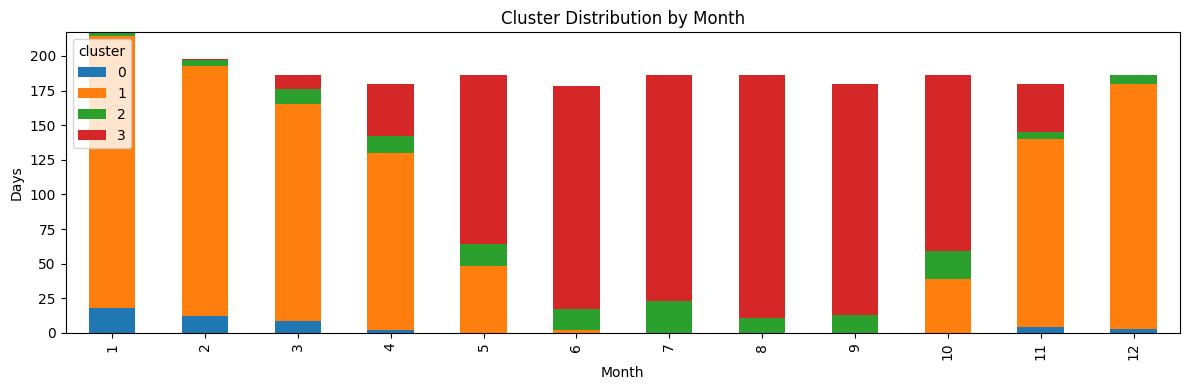

In [60]:
# Monthly distribution per cluster — does it rediscover seasonality?
df["month"] = df.index.month
fig, ax = plt.subplots(figsize=(12, 4))
df.groupby(["month", "cluster"]).size().unstack().plot.bar(stacked=True, ax=ax)
ax.set_title("Cluster Distribution by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Days")
plt.tight_layout()
plt.show()

## 4. t-SNE Visualization

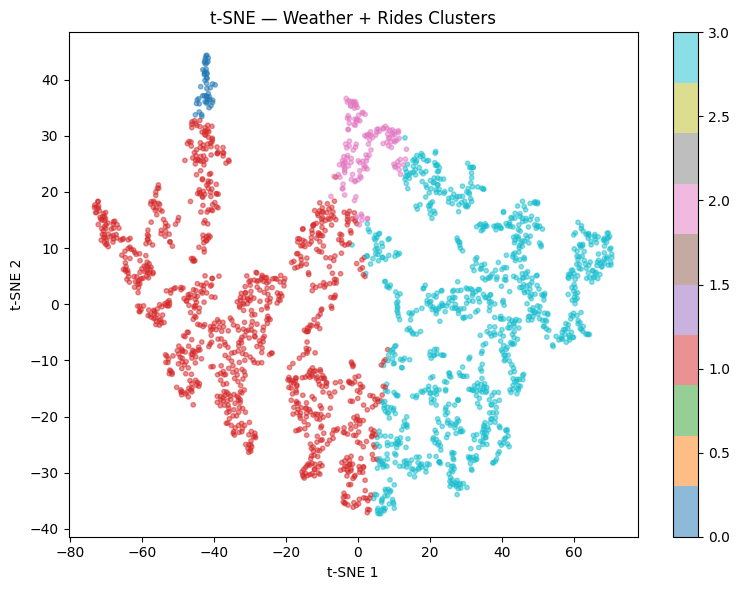

In [61]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
coords = tsne.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=df["cluster"], cmap="tab10", alpha=0.5, s=10)
plt.colorbar(scatter, ax=ax)
ax.set_title("t-SNE — Weather + Rides Clusters")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

## 5. PCA — Weather Index
Find the right number of PCA dimensions by elbow, then use the best PC(s) as a weather index.

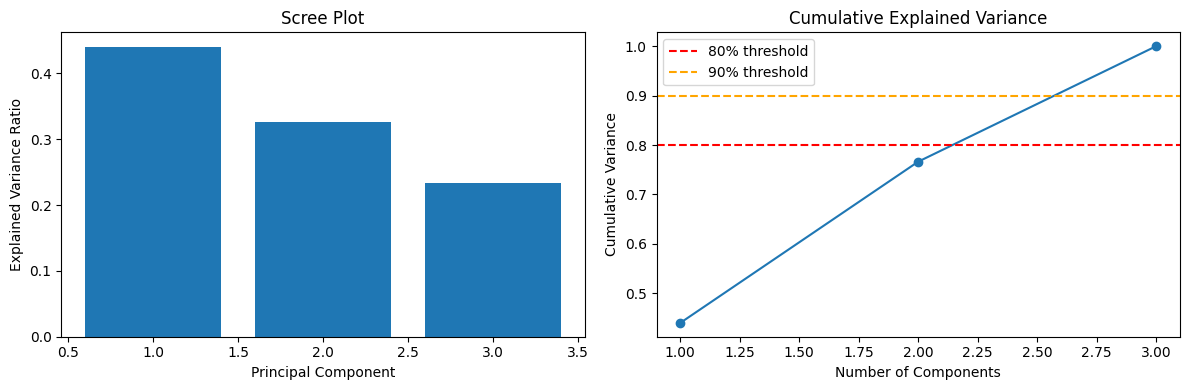

Cumulative variance:
  PC1–PC1: 0.440
  PC1–PC2: 0.766
  PC1–PC3: 1.000


In [62]:
# PCA on weather vars only
pca_vars = ["temp_min_c", "rain_sum_mm", "snowfall_sum_cm"]  # exclude wind
X_weather = StandardScaler().fit_transform(df[pca_vars])
pca = PCA()
pca.fit(X_weather)

cumvar = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, len(pca_vars)+1), pca.explained_variance_ratio_)
axes[0].set_title("Scree Plot")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")

axes[1].plot(range(1, len(pca_vars)+1), cumvar, marker="o")
axes[1].axhline(0.8, color="red", linestyle="--", label="80% threshold")
axes[1].axhline(0.9, color="orange", linestyle="--", label="90% threshold")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Variance")
axes[1].legend()
plt.tight_layout()
plt.show()

print("Cumulative variance:")
for i, v in enumerate(cumvar):
    print(f"  PC1–PC{i+1}: {v:.3f}")

In [63]:
# PC loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_vars,
    columns=[f"PC{i+1}" for i in range(len(pca_vars))]
).round(3)
print("PC Loadings:")
loadings

PC Loadings:


,PC1,PC2,PC3
temp_min_c,0.695,-0.008,0.719
rain_sum_mm,0.483,0.746,-0.458
snowfall_sum_cm,-0.533,0.666,0.522


In [67]:
# Choose number of components (adjust based on elbow above)
N_COMPONENTS = 2  # or 2 if cumvar warrants it

scores = pca.transform(X_weather)[:, :N_COMPONENTS]

if N_COMPONENTS == 1:
    df["weather_index"] = scores[:, 0]
    # Flip so positive = better riding weather
    if df["weather_index"].corr(df["total_rides"]) < 0:
        df["weather_index"] *= -1
        print("Flipped PC1 sign: positive = better riding weather")
    print(f"Correlation with rides: {df['weather_index'].corr(df['total_rides']):.3f}")
else:
    for i in range(N_COMPONENTS):
        col = f"weather_pc{i+1}"
        df[col] = scores[:, i]
        r = df[col].corr(df["total_rides"])
        print(f"PC{i+1} correlation with rides: {r:.3f}")

PC1 correlation with rides: 0.594
PC2 correlation with rides: -0.232


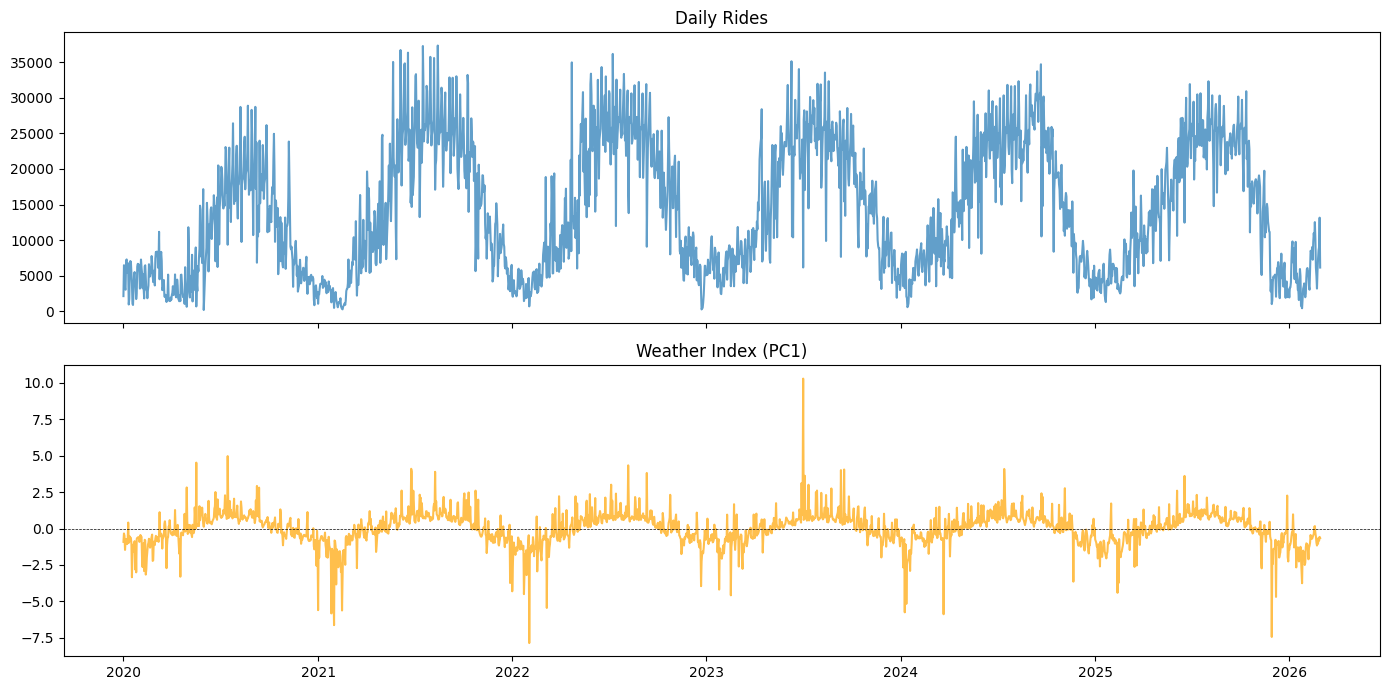

In [68]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(df.index, df["total_rides"], alpha=0.7)
axes[0].set_title("Daily Rides")
axes[1].plot(df.index, df["weather_index"], alpha=0.7, color="orange")
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_title("Weather Index (PC1)")
plt.tight_layout()
plt.show()

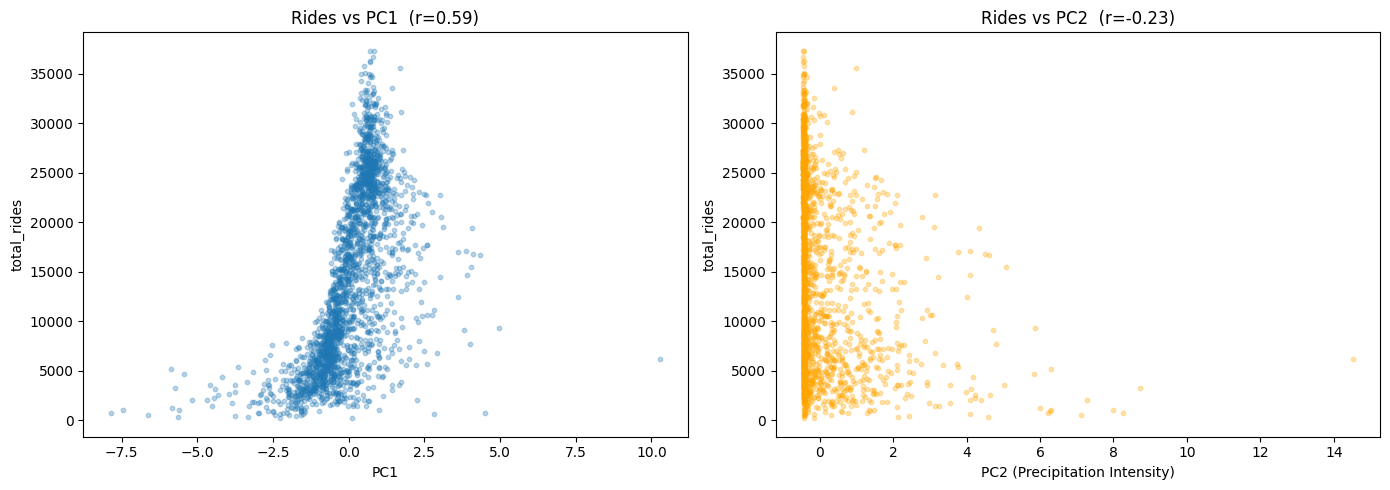

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["weather_pc1"], df["total_rides"], alpha=0.3, s=10)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("total_rides")
axes[0].set_title(f"Rides vs PC1  (r={df['total_rides'].corr(df['weather_pc1']):.2f})")

axes[1].scatter(df["weather_pc2"], df["total_rides"], alpha=0.3, s=10, color="orange")
axes[1].set_xlabel("PC2 (Precipitation Intensity)")
axes[1].set_ylabel("total_rides")
axes[1].set_title(f"Rides vs PC2  (r={df['total_rides'].corr(df['weather_pc2']):.2f})")

plt.tight_layout()
plt.show()